In [2]:
import geopandas as gpd
import earthaccess
from peatfire import data_path
import matplotlib.pyplot as plt
import rioxarray
import xarray as xr

In [ ]:
x = gpd.read_file(data_path('interim', 'soil', 'ssurgo', 'nc_soil_ssurgo.gpkg'), masked=True)
y = 

DataSourceError: sqlite3_prepare_v2(SELECT COUNT(*) FROM sqlite_master WHERE name IN ('gpkg_metadata', 'gpkg_metadata_reference') AND type IN ('table', 'view')) failed: attempt to write a readonly database; attempt to write a readonly database

In [ ]:
nc = gpd.read_file(data_path('processed', 'boundaries', 'nc_boundary.gpkg'))

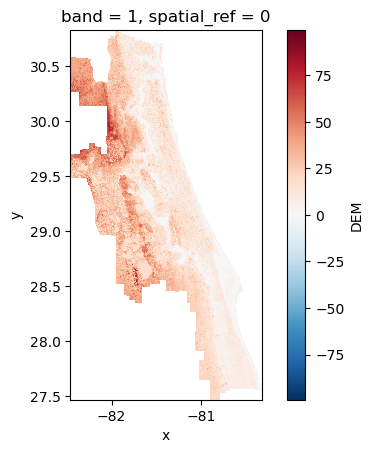

In [19]:
glo30 = rioxarray.open_rasterio(
    data_path(
        'processed', 'topography',
        'GLO30_DEM', 'GLO30_DEM.tif'
    ),
    masked=True
)

nc = nc.to_crs(glo30.rio.crs)

fig, ax = plt.subplots()

nc.plot(ax=ax, facecolor='none')
glo30.plot(ax=ax)


In [22]:
glo30

<xarray.DataArray (band: 1, y: 12489, x: 7935)> Size: 396MB
array([[[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]]], shape=(1, 12489, 7935), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 100kB 30.83 30.83 30.83 30.83 ... 27.47 27.46 27.46
  * x            (x) float64 63kB -82.46 -82.46 -82.46 ... -80.32 -80.32 -80.32
    spatial_ref  int64 8B 0
Attributes: (12/14)
    TIFFTAG_SOFTWARE:        GDAL 3.10.2e (3100211) (4.7.0;1743;3.0.3;2.1.6;0...
    AREA_OR_POINT:           Area
    STATISTICS_COUNT:        40292672.0
    STATISTICS_COVARIANCES:  205.6148029734686
    STATISTICS_MAXIMUM:      99.214424133301
    STATISTICS_MEAN:         19.255488241746
    ...                      ...
    STATISTICS_SKIPFACTORX:  1
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       14.33927484127
    scale_factor:            1.0
    add_offset:              0.0
    long_name:               DEM

overlay viirs on modis

In [ ]:
viirs_snpp = gpd.read_file(
    data_path(
        'processed', 'fire',
        'viirs',
        'viirs_snpp_archive_nc.gpkg'
    )
)

mcd64a1_test2 = rioxarray.open_rasterio(
    data_path(
        'processed', 'fire',
        'MCD64A1_061',
        'MCD64A1_A2026060_nc.tif'
    ),
    masked=True
)

<Axes: >

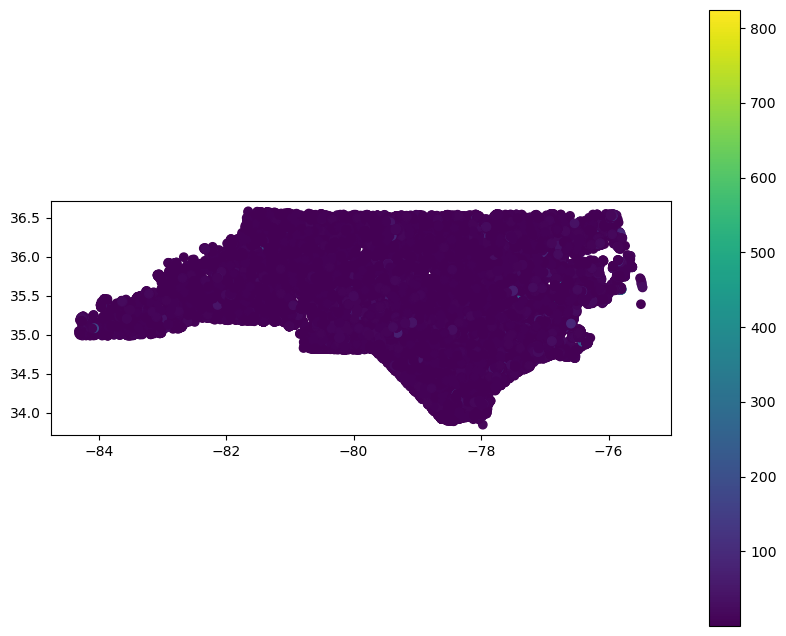

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))

viirs_snpp.plot(ax=ax, column='FRP', legend=True, cmap='viridis')

gabam vs modis comparison

In [8]:
nc = gpd.read_file(data_path('processed', 'boundaries', 'nc_boundary.gpkg'))

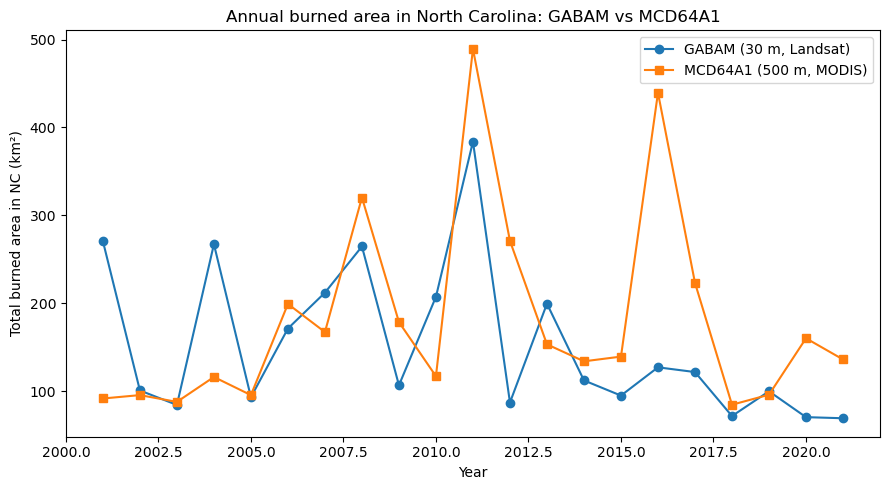

In [ ]:
import numpy as np, pandas as pd, xarray as xr, rioxarray
from collections import defaultdict
import matplotlib.pyplot as plt
from rasterio.enums import Resampling   # move this up with your other imports

def burned_area_km2(binary, equal_area="EPSG:5070", resolution=30):
    """binary: boolean DataArray (True = burned), with a CRS set. Returns km²."""
    da = binary.astype("uint8")
    if da.rio.crs.is_geographic:                       # GABAM (degrees) -> reproject to equal-area meters
        da = da.rio.reproject(equal_area, resolution=resolution,
                              resampling=Resampling.nearest)
    t = da.rio.transform()                             # now constant pixel area (sinusoidal or Albers)
    return float((da.values == 1).sum()) * abs(t.a * t.e) / 1e6

# ---------------------------------------------------------------------------
# MODIS: group monthly clipped tifs by year, OR the months into an annual mask
# ---------------------------------------------------------------------------
mcd_dir = data_path('processed', 'fire', 'MCD64A1_061')
by_year = defaultdict(list)
for f in sorted(mcd_dir.glob("MCD64A1_*_nc.tif")):
    year = int(f.stem.split("_")[1][1:5])             # 'MCD64A1_A2017001_nc' -> 'A2017001' -> 2017
    by_year[year].append(f)

mcd_area = {}
for year, files in by_year.items():
    months = []
    for f in files:
        da = rioxarray.open_rasterio(f, masked=True).squeeze("band", drop=True)
        months.append(da > 0)                         # burned = BurnDate 1-366; 0/-1/-2/NaN -> False
    annual = xr.concat(months, dim="m").max("m")      # logical OR across the year's months
    annual = annual.rio.write_crs(months[0].rio.crs)
    mcd_area[year] = burned_area_km2(annual)

# ---------------------------------------------------------------------------
# GABAM: one annual tif each
# ---------------------------------------------------------------------------
gabam_dir = data_path('processed', 'fire', 'gabam')
gabam_area = {}
for f in sorted(gabam_dir.glob("gabam_*_nc.tif")):
    year = int(f.stem.split("_")[1])
    da = rioxarray.open_rasterio(f, masked=True).squeeze("band", drop=True)
    gabam_area[year] = burned_area_km2(da > 0)

# ---------------------------------------------------------------------------
# Combine + plot
# ---------------------------------------------------------------------------
df = (pd.DataFrame({"gabam_km2": pd.Series(gabam_area),
                    "mcd64_km2": pd.Series(mcd_area)})
        .sort_index().rename_axis("year").reset_index())
df = df[(df.year >= 2001) & (df.year <= 2021)]   # drop 2000 (MODIS partial) & 2022+ (no GABAM)
df.to_csv(data_path('processed', 'fire', 'gabam_vs_mcd64_nc_area.csv'), index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df.year, df.gabam_km2, marker="o", label="GABAM (30 m, Landsat)")
ax.plot(df.year, df.mcd64_km2, marker="s", label="MCD64A1 (500 m, MODIS)")
ax.set_xlabel("Year"); ax.set_ylabel("Total burned area in NC (km²)")
ax.set_title("Annual burned area in North Carolina: GABAM vs MCD64A1")
ax.legend(); fig.tight_layout()
fig.savefig('../outputs/figures/fire/gabam_vs_mcd64_nc_area.png', dpi=150)

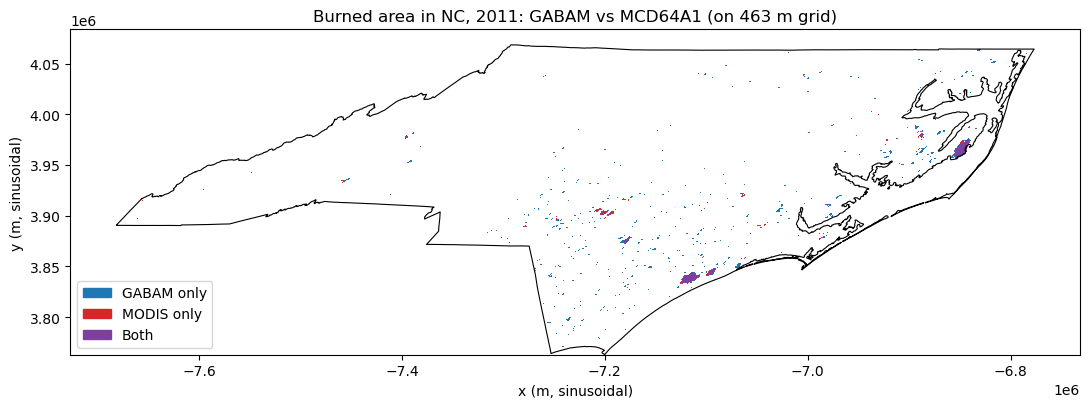

In [9]:
import numpy as np, xarray as xr, rioxarray, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from rasterio.enums import Resampling

year = 2011

# --- MODIS annual binary (sinusoidal), OR over the year's monthly files ---
months = [rioxarray.open_rasterio(f, masked=True).squeeze("band", drop=True) > 0
          for f in by_year[year]]
m = xr.concat(months, "m").max("m").rio.write_crs(months[0].rio.crs).astype("uint8")

# --- GABAM annual binary (4326), open light (uint8, not masked float) ---
g = rioxarray.open_rasterio(gabam_dir / f"gabam_{year}_nc.tif").squeeze("band", drop=True)
g = (g == 1).astype("uint8")

# --- put GABAM on MODIS's grid so the two align; max() = "any 30 m burn lights the cell" ---
g_on_m = g.rio.reproject_match(m, resampling=Resampling.max)

# --- build a categorical raster: 1=GABAM only, 2=MODIS only, 3=both ---
gb, mb = g_on_m.values, m.values
cat = np.zeros(mb.shape, dtype="uint8")
cat[(gb == 1) & (mb == 0)] = 1
cat[(gb == 0) & (mb == 1)] = 2
cat[(gb == 1) & (mb == 1)] = 3
cat_ma = np.ma.masked_where(cat == 0, cat)          # unburned -> transparent

# --- plot ---
left, bottom, right, top = m.rio.bounds()
cmap = ListedColormap(["#1f77b4", "#d62728", "#7e3f9e"])  # blue, red, purple

fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(cat_ma, extent=[left, right, bottom, top], origin="upper",
          cmap=cmap, vmin=1, vmax=3, interpolation="nearest")
nc.to_crs(m.rio.crs).boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.set_title(f"Burned area in NC, {year}: GABAM vs MCD64A1 (on 463 m grid)")
ax.set_xlabel("x (m, sinusoidal)"); ax.set_ylabel("y (m, sinusoidal)")
ax.legend(handles=[Patch(color="#1f77b4", label="GABAM only"),
                   Patch(color="#d62728", label="MODIS only"),
                   Patch(color="#7e3f9e", label="Both")], loc="lower left")
fig.tight_layout()
fig.savefig(f'../outputs/figures/fire/overlay_{year}_nc.png', dpi=150)